<a href="https://colab.research.google.com/github/TimothyKeng/For-fun/blob/main/E_Commerce_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Behavioral Analysis

In [3]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings. filterwarnings('ignore')
%matplotlib inline

from google.colab import files

uploaded = files.upload()
import utils
df= utils.load_data(filepath= 'orders.csv')

Saving orders.csv to orders (1).csv
Saving utils.py to utils.py


##Payment Methods

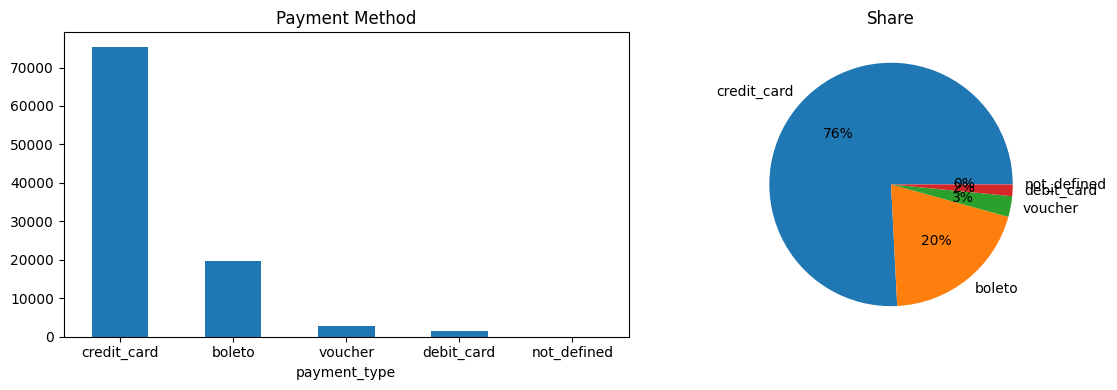

,Payment Type,Count
0,credit_card,75387
1,boleto,19784
2,voucher,2739
3,debit_card,1527
4,not_defined,3


In [10]:
pt= df['payment_type'].value_counts()

fig, ax= plt.subplots(1,2, figsize= (12,4))

# bar chart
pt.plot(kind= 'bar', ax=ax[0])
ax[0].set_title('Payment Method')
ax[0].tick_params(axis= 'x', rotation= 0)

# pie chart
ax[1].pie(pt, labels= pt.index, autopct= '%1.0f%%')
ax[1].set_title('Share')

# Create table w/ columns and
payment_table= pt.reset_index()
payment_table.columns= ['Payment Type', 'Count']

styled_payment_table = payment_table.style.set_table_styles([{'selector': 'thead th', 'props': [('border-bottom','2px solid black')]}])


plt.tight_layout()
plt.show()
styled_payment_table

Order Value & Installments

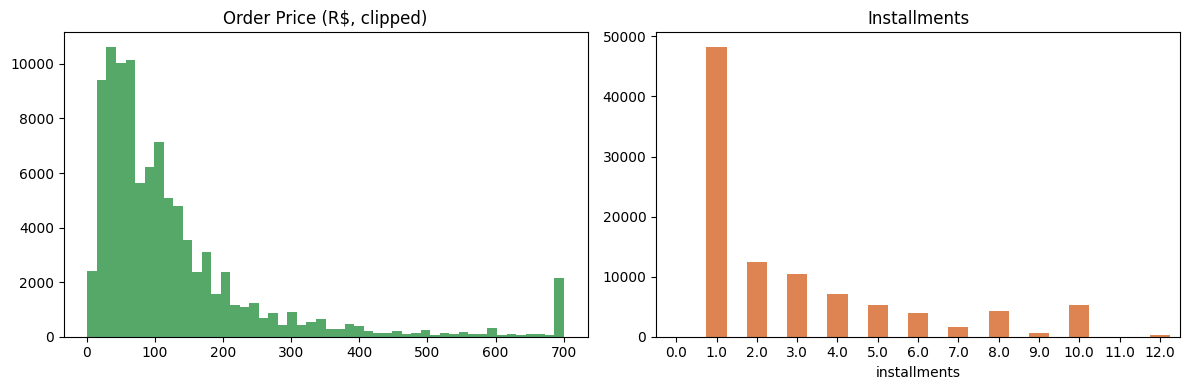

mean price: R$137.75
mean freight: R$22.87


In [5]:
fig, ax= plt.subplots(1,2,figsize=(12,4))
ax[0].hist(df['price'].clip(upper=df['price'].quantile(.98)),bins= 50, color= '#55a868')
ax[0].set_title('Order Price (R$, clipped)')

df['installments'].dropna().clip(upper= 12).value_counts().sort_index().plot(kind='bar', ax=ax[1], color= '#dd8452')
ax[1].set_title('Installments')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print(f'mean price: R${df.price.mean():.2f}')
print(f'mean freight: R${df.freight.mean():.2f}')

## Review scores

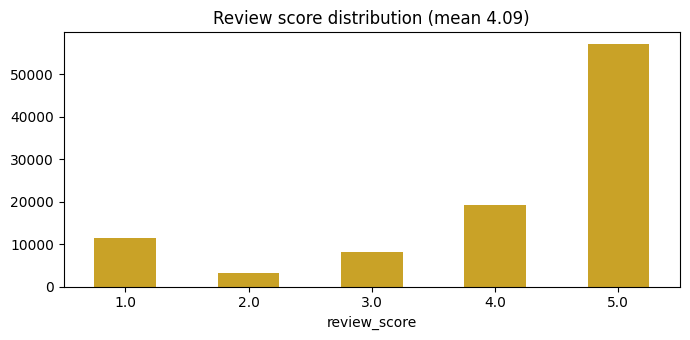

In [7]:
rs= df['review_score'].round().value_counts().sort_index()
fig, ax= plt.subplots(figsize=(7,3.5)); rs.plot(kind= 'bar', ax=ax, color= '#c9a227')
ax.set_title('Review score distribution (mean %.2f)'%df.review_score.mean())
ax.tick_params(axis= 'x', rotation= 0)

plt.tight_layout()
plt.show()

## How does delivery speed affect the review?

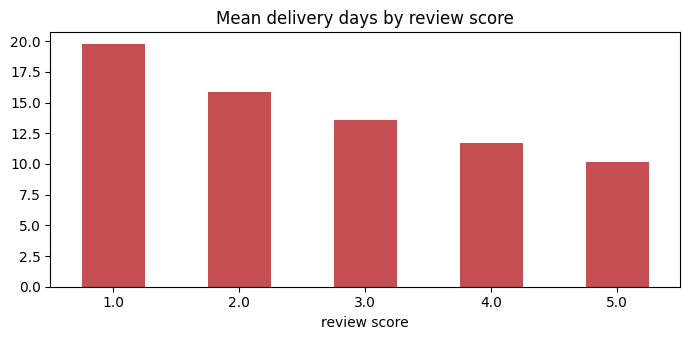

corr(delivery_days, review): -0.343


In [9]:
df['purchase']= pd.to_datetime(df['order_purchase_timestamp'], errors= 'coerce')
df['delivered']= pd.to_datetime(df['order_delivered_customer_date'], errors= 'coerce')
df['delivery_days']= (df['delivered'] - df['purchase']).dt.days
d= df.dropna(subset=['delivery_days', 'review_score'])
d= d[(d.delivery_days >= 0) & (d.delivery_days <60)]
g= d.groupby(d['review_score'].round())['delivery_days'].mean()

fig, ax= plt.subplots(figsize= (7,3.5))
g.plot(kind= 'bar', ax=ax, color= '#c44e52')
ax.set_title('Mean delivery days by review score')
ax.set_xlabel('review score')
ax.tick_params(axis= 'x', rotation= 0)
plt.tight_layout()
plt.show()

print('corr(delivery_days, review):', round(d['delivery_days'].corr(d['review_score']),3))

## Key findings

- 99,441 orders, 97% delivered; mean order R$137.75 + R$22.87 freight.
- Credit card dominates (76%), then boleto (20%) (a Brazil-specific bank slip), voucher and debit trailing
- Installment culture is real- ~half of orders are paid in one installment, but the long tail spreads purchases over 2-12 months (credit-card installments are a core Brazilian e-commerce behavior)
- Customers are satisfied on average (mean review 4.09/5), but reviews are bimodal (lots of 5s and chunk of 1s)
- Slow delivery drags reviews down - mean delivery time is markedly longer for 1 star than 5 star orders (negative delivery-days <-> score correlation); logistics, not price, is the satisfaction lever